In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# 1. Read Data

In [6]:
df_U = pd.read_csv('plot_U_inf.csv')

df_U.iloc[:, 1:] = df_U.iloc[:, 1:] * 0.02

df_H = pd.read_csv('plot_H.csv')

print(df_U.head())

print(df_H.head())

       x      Run1     Run10     Run11     Run12      Run2      Run3  \
0  0.000  1.770894  2.099213  2.839908  4.377565  1.679385  1.591460   
1  0.049  0.503340  1.381458  2.705701  3.870418  0.472069  0.471027   
2  0.081  1.229707  0.394472  2.376616  2.909608  1.162773  1.087169   
3  0.124  1.962447  0.063086  2.130172  1.347945  1.849344  1.753032   
4  0.163  1.249213  0.357848  2.056924  0.438885  1.186806  1.130267   

       Run4      Run5      Run6      Run7      Run8      Run9   Run10.1  \
0  3.792292  4.048320  3.652872  0.521169  0.553507  0.602413  0.759297   
1  1.050639  0.929241  0.969829  0.189124  0.188070  0.194643  0.611811   
2  2.671340  2.816996  2.468908  0.356169  0.375584  0.409750  0.596460   
3  4.440871  4.912525  4.081288  0.574619  0.604276  0.655303  0.508368   
4  2.406481  2.636305  2.159797  0.404421  0.419357  0.449574  0.544708   

    Run11.1   Run12.1  
0  1.355532  4.472165  
1  1.336763  3.989002  
2  1.265919  3.170517  
3  1.177146  1.92115

# 2. Definite function

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
from matplotlib.lines import Line2D

# ==============================
# 科学出版物配色
# ==============================
scientific_colors = {
    'blue':   '#1f77b4',
    'red':    '#d62728',
    'green':  '#2ca02c',
    'orange': '#ff7f0e',
    'purple': '#9467bd',
    'brown':  '#8c564b',
    'pink':   '#e377c2',
    'gray':   '#7f7f7f',
    'yellow': '#bcbd22',
    'cyan':   '#17becf',
}

def plot_runs_template(
    df,
    runs,
    ylim=None,
    title=None,
    panel_label=None,
    legend_labels=None
):
    """
    论文级 Run* 点线图（平滑线 + 原始散点 + 代理 legend + 自定义 legend 名称）

    Parameters
    ----------
    df : pandas.DataFrame
        包含 'x' 和 Run* 列
    runs : list or str
        例如 ['Run1', 'Run5'] 或 'Run1'
    ylim : tuple, optional
        y 轴范围，例如 (0, 120)
    title : str, optional
        图标题
    panel_label : str, optional
        子图编号，例如 '(a)'
    legend_labels : dict, optional
        自定义 legend 名称，例如 {'Run1':'Case A', 'Run5':'Case B'}
    """

    if isinstance(runs, str):
        runs = [runs]

    missing = [r for r in runs if r not in df.columns]
    if missing:
        raise ValueError(f"以下列不存在于 df 中: {missing}")

    datasets = [(run, df["x"].values, df[run].values) for run in runs]
    color_list = list(scientific_colors.values())

    fig, ax = plt.subplots(1, figsize=(6, 5))
    legend_handles = []

    for i, (label, x_original, y_original) in enumerate(datasets):
        color = color_list[i % len(color_list)]

        mask = ~np.isnan(x_original) & ~np.isnan(y_original)
        x_original = x_original[mask]
        y_original = y_original[mask]

        # legend 显示名称
        display_label = legend_labels[label] if legend_labels is not None and label in legend_labels else label

        # 平滑曲线 + 散点
        if len(x_original) > 3:
            x_smooth = np.linspace(x_original.min(), x_original.max(), 300)
            try:
                spl = make_interp_spline(x_original, y_original, k=3)
                y_smooth = spl(x_smooth)
                ax.plot(
                    x_smooth, y_smooth,
                    linewidth=1.5,
                    linestyle='--',
                    color=color
                )
                ax.scatter(
                    x_original, y_original,
                    s=55,
                    facecolors='none',
                    edgecolors=color,
                    linewidths=1.2,
                    zorder=3
                )
            except Exception:
                ax.plot(x_original, y_original, linewidth=1.5, color=color)
                ax.scatter(
                    x_original, y_original,
                    s=55,
                    facecolors='none',
                    edgecolors=color,
                    linewidths=1.2,
                    zorder=3
                )
        else:
            ax.plot(x_original, y_original, linewidth=1.5, color=color)
            ax.scatter(
                x_original, y_original,
                s=55,
                facecolors='none',
                edgecolors=color,
                linewidths=1.2,
                zorder=3
            )

        # legend 代理 artist
        legend_handles.append(
            Line2D(
                [0], [0],
                color=color,
                linestyle='--',
                linewidth=1.5,
                marker='o',
                markerfacecolor='none',
                markeredgecolor=color,
                markersize=7,
                label=display_label
            )
        )

    # ==============================
    # 图形细节
    # ==============================
    ax.set_xlabel(r"$x \, (m)$")
    ax.set_ylabel(r"$U/U_\infty \, (-)$")

    if title is not None:
        ax.set_title(title, fontsize=12)

    if panel_label is not None:
        ax.text(
            -0.12, 1.05, panel_label,
            transform=ax.transAxes,
            fontsize=18,
            fontweight='bold',
            va='top',
            ha='left'
        )

    ax.xaxis.set_tick_params(direction='in', which='both')
    ax.yaxis.set_tick_params(direction='in', which='both')
    ax.xaxis.set_ticks_position('both')
    ax.yaxis.set_ticks_position('both')

    ax.grid(True)

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_color('black')

    ax.legend(
        handles=legend_handles,
        loc="best",
        frameon=True,
        ncol=1
    )

    x_max = max(arr[1].max() for arr in datasets)
    ax.set_xlim(0, x_max)

    if ylim is not None:
        ax.set_ylim(ylim)

    plt.tight_layout()
    return fig, ax


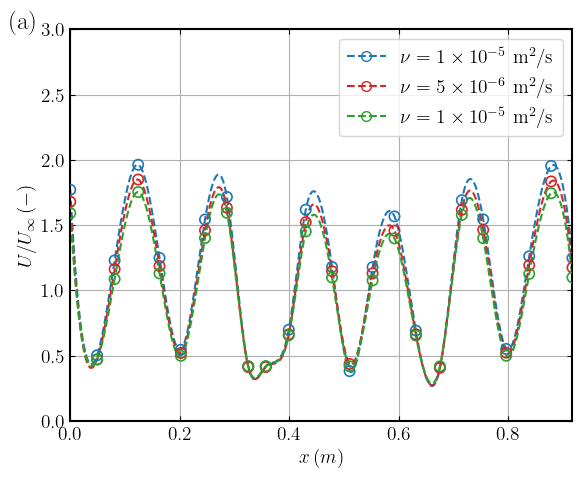

In [8]:
plt.rcParams.update({
    'font.size': 14,
    'font.family': 'Times New Roman',
    "text.usetex": True
})

legend_map1 = {
    "Run1": r"$\nu = 1\times 10^{-5}\ \mathrm{m^2/s}$",
    "Run2": r"$\nu = 5\times 10^{-6}\ \mathrm{m^2/s}$",
    "Run3": r"$\nu = 1\times 10^{-5}\ \mathrm{m^2/s}$"
}


fig,ax=plot_runs_template(
    df_U,
    ["Run1", "Run2", "Run3"],
    ylim=(0, 3),
    panel_label="(a)",
    legend_labels=legend_map1
)

#plt.savefig('Figa_U_inf.png', dpi=600, bbox_inches='tight')

plt.show()


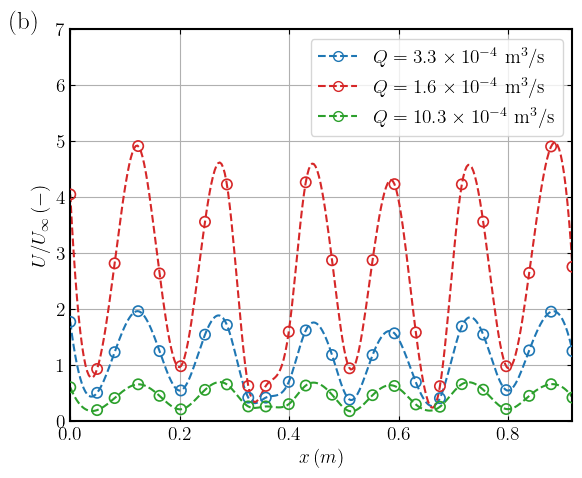

In [ ]:
legend_map2 = {
    "Run1": r"$Q = 3.3\times 10^{-4}\ \mathrm{m^3/s}$",
    "Run5": r"$Q = 1.6\times 10^{-4}\ \mathrm{m^3/s}$",
    "Run9": r"$Q = 10.3\times 10^{-4}\ \mathrm{m^3/s}$"
}

fig,ax= plot_runs_template(
    df_U,
    ["Run1", "Run5", "Run9"],
    ylim=(0, 7),
    panel_label="(b)",
    legend_labels=legend_map2
)

#plt.savefig('Figb_U_inf.png', dpi=600, bbox_inches='tight')
plt.show()

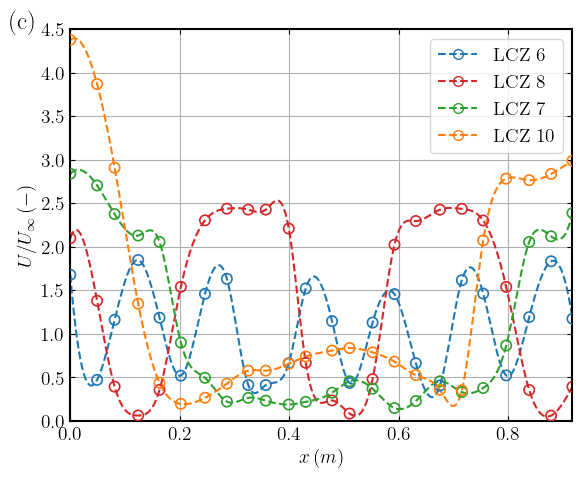

In [9]:
plt.rcParams.update({
    'font.size': 14,
    'font.family': 'Times New Roman',
    "text.usetex": True
})

legend_map3 = {
    "Run2": r'LCZ 6',
    "Run10": r'LCZ 8',
    "Run11": r'LCZ 7',
    "Run12": r'LCZ 10',
}


fig,ax=plot_runs_template(
    df_U,
    ["Run2", "Run10", "Run11",'Run12'],
    ylim=(0, 4.5),
    panel_label="(c)",
    legend_labels=legend_map3
)

#plt.savefig('Figc_U_inf.png', dpi=600, bbox_inches='tight')
plt.show()

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
from matplotlib.lines import Line2D

# ==============================
# 科学出版物配色
# ==============================
scientific_colors = {
    'blue':   '#1f77b4',
    'red':    '#d62728',
    'green':  '#2ca02c',
    'orange': '#ff7f0e',
    'purple': '#9467bd',
    'brown':  '#8c564b',
    'pink':   '#e377c2',
    'gray':   '#7f7f7f',
    'yellow': '#bcbd22',
    'cyan':   '#17becf',
    'navy':   '#2E86AB',
    'olive':  '#808000'
}

def plot_runs_height_template(
    df,
    runs,
    ylim=None,
    title=None,
    panel_label=None,
    legend_labels=None
):
    """
    论文级 Run* 点线图（平滑线 + 原始散点 + 代理 legend + 自定义 legend 名称）

    Parameters
    ----------
    df : pandas.DataFrame
        包含 'x' 和 Run* 列
    runs : list or str
        例如 ['Run1', 'Run5'] 或 'Run1'
    ylim : tuple, optional
        y 轴范围，例如 (0, 120)
    title : str, optional
        图标题
    panel_label : str, optional
        子图编号，例如 '(a)'
    legend_labels : dict, optional
        自定义 legend 名称，例如 {'Run1':'Case A', 'Run5':'Case B'}
    """

    if isinstance(runs, str):
        runs = [runs]

    missing = [r for r in runs if r not in df.columns]
    if missing:
        raise ValueError(f"以下列不存在于 df 中: {missing}")

    datasets = [(run, df["x"].values, df[run].values) for run in runs]
    color_list = list(scientific_colors.values())

    fig, ax = plt.subplots(1, figsize=(6, 5))
    legend_handles = []

    for i, (label, x_original, y_original) in enumerate(datasets):
        color = color_list[i % len(color_list)]

        mask = ~np.isnan(x_original) & ~np.isnan(y_original)
        x_original = x_original[mask]
        y_original = y_original[mask]

        # legend 显示名称
        display_label = legend_labels[label] if legend_labels is not None and label in legend_labels else label

        # 平滑曲线 + 散点
        if len(x_original) > 3:
            x_smooth = np.linspace(x_original.min(), x_original.max(), 300)
            try:
                spl = make_interp_spline(x_original, y_original, k=3)
                y_smooth = spl(x_smooth)
                ax.plot(
                    x_smooth, y_smooth,
                    linewidth=1.5,
                    linestyle='-',
                    color=color
                )
                ax.scatter(
                    x_original, y_original,
                    s=55,
                    marker='^',
                    #facecolors='none',
                    edgecolors=color,
                    linewidths=1.2,
                    zorder=3
                )
            except Exception:
                ax.plot(x_original, y_original, linewidth=1.5, color=color)
                ax.scatter(
                    x_original, y_original,
                    s=55,
                    marker='^',
                    #facecolors='none',
                    edgecolors=color,
                    linewidths=1.2,
                    zorder=3
                )
        else:
            ax.plot(x_original, y_original, linewidth=1.5, color=color)
            ax.scatter(
                x_original, y_original,
                s=55,
                marker='^',
                #facecolors='none',
                edgecolors=color,
                linewidths=1.2,
                zorder=3
            )

        # legend 代理 artist
        legend_handles.append(
            Line2D(
                [0], [0],
                color=color,
                linestyle='-',
                linewidth=1.5,
                marker='^',
                #markerfacecolor='none',
                markeredgecolor=color,
                markersize=7,
                label=display_label
            )
        )

    # ==============================
    # 图形细节
    # ==============================
    ax.set_xlabel(r"$x \, (m)$")
    ax.set_ylabel(r"$h_L \, (m)$")

    if title is not None:
        ax.set_title(title, fontsize=12)

    if panel_label is not None:
        ax.text(
            -0.12, 1.05, panel_label,
            transform=ax.transAxes,
            fontsize=18,
            fontweight='bold',
            va='top',
            ha='left'
        )

    ax.xaxis.set_tick_params(direction='in', which='both')
    ax.yaxis.set_tick_params(direction='in', which='both')
    ax.xaxis.set_ticks_position('both')
    ax.yaxis.set_ticks_position('both')

    ax.grid(True)

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_color('black')

    ax.legend(
        handles=legend_handles,
        loc="best",
        frameon=True,
        ncol=3,
        fontsize=12
    )

    x_max = max(arr[1].max() for arr in datasets)
    ax.set_xlim(0, x_max)

    if ylim is not None:
        ax.set_ylim(ylim)

    plt.tight_layout()

    return fig, ax


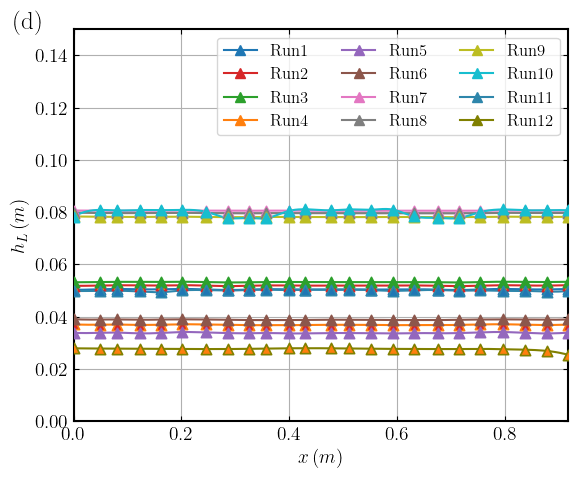

In [17]:

fig,ax=plot_runs_height_template(
    df_H,
    ["Run1", "Run2","Run3", "Run4",
     "Run5", "Run6", "Run7", "Run8",
     "Run9","Run10","Run11","Run12"
     ],
    panel_label="(d)",
    ylim=(0, 0.15)
)

plt.savefig('Fig3d_H.png', dpi=600, bbox_inches='tight')

plt.show()

# 3. Combine Data

In [18]:
from PIL import Image

def merge_2x2_exact(image_paths, output_path):
    # 1. 加载图片
    imgs = [Image.open(p) for p in image_paths]
    
    # 2. 获取单张图片的宽高 (假设所有图一样大，取第一张即可)
    w, h = imgs[0].size
    
    # 3. 创建画布：宽高各翻一倍
    canvas = Image.new('RGB', (w * 2, h * 2))
    
    # 4. 粘贴到对应位置
    # 第一行
    canvas.paste(imgs[0], (0, 0))   # 左上
    canvas.paste(imgs[1], (w, 0))   # 右上
    
    # 第二行
    canvas.paste(imgs[2], (0, h))   # 左下
    canvas.paste(imgs[3], (w, h))   # 右下
    
    # 5. 保存结果
    canvas.save(output_path, quality=95)
    print(f"拼接成功！输出尺寸为: {w*2}x{h*2}")

# 使用方法：
paths = ['Fig3a_U_inf.png', 'Fig3b_U_inf.png', 'Fig3c_U_inf.png', 'Fig3d_H.png']

merge_2x2_exact(paths, 'Fig3.jpg')

拼接成功！输出尺寸为: 6988x5740
